In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/cleaned_merged.csv')
df

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month
0,01-01-2023,East US,VM,88,1959,470,104.97,0.99,1,2023-01
1,01-01-2023,East US,Storage,92,1595,388,104.97,0.99,1,2023-01
2,01-01-2023,East US,Container,70,621,414,104.97,0.99,1,2023-01
3,01-01-2023,West US,VM,60,1982,287,104.97,0.99,1,2023-01
4,01-01-2023,West US,Storage,85,1371,351,104.97,0.99,1,2023-01
...,...,...,...,...,...,...,...,...,...,...
1075,31-03-2023,North Europe,Storage,84,734,412,97.35,1.27,0,2023-03
1076,31-03-2023,North Europe,Container,98,1650,422,97.35,1.27,0,2023-03
1077,31-03-2023,Southeast Asia,VM,74,1802,493,97.35,1.27,0,2023-03
1078,31-03-2023,Southeast Asia,Storage,77,776,306,97.35,1.27,0,2023-03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 1080 non-null   object 
 1   region               1080 non-null   object 
 2   resource_type        1080 non-null   object 
 3   usage_cpu            1080 non-null   int64  
 4   usage_storage        1080 non-null   int64  
 5   users_active         1080 non-null   int64  
 6   economic_index       1080 non-null   float64
 7   cloud_market_demand  1080 non-null   float64
 8   holiday              1080 non-null   int64  
 9   month                1080 non-null   object 
dtypes: float64(2), int64(4), object(4)
memory usage: 84.5+ KB


In [ ]:
df['date'][0]

'01-01-2023'

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,74.651852,1242.477778,352.694444,98.930444,1.006667,0.277778
std,14.549621,432.444284,86.280150,8.779973,0.100998,0.448111
min,50.000000,500.000000,200.000000,73.800000,0.800000,0.000000
25%,62.000000,881.750000,283.000000,92.980000,0.940000,0.000000
50%,75.000000,1262.000000,353.000000,99.645000,1.015000,0.000000
75%,87.000000,1609.000000,427.000000,103.610000,1.080000,1.000000
max,99.000000,1995.000000,499.000000,118.860000,1.270000,1.000000


In [ ]:
df['date']=pd.to_datetime(df['date'], format='%d-%m-%Y')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 1080 non-null   datetime64[ns]
 1   region               1080 non-null   object        
 2   resource_type        1080 non-null   object        
 3   usage_cpu            1080 non-null   int64         
 4   usage_storage        1080 non-null   int64         
 5   users_active         1080 non-null   int64         
 6   economic_index       1080 non-null   float64       
 7   cloud_market_demand  1080 non-null   float64       
 8   holiday              1080 non-null   int64         
 9   month                1080 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 84.5+ KB


In [ ]:
df.drop('month', axis=1, inplace=True)


In [ ]:
df['month']=df['date'].dt.month

In [ ]:
df['date_ind']=df['date'].dt.day

In [ ]:
df['year']=df['date'].dt.year

In [ ]:
df['is_weekend'] = df['date'].dt.dayofweek >= 5

In [ ]:
#(Monday=0, Sunday=6)
df['day_of_week_int'] = df['date'].dt.dayofweek
display(df[['date', 'day_of_week_int']].head())

# day of the week name
df['day_of_week_name'] = df['date'].dt.day_name()
display(df[['date', 'day_of_week_name']].head())

,date,day_of_week_int
0,2023-01-01,6
1,2023-01-01,6
2,2023-01-01,6
3,2023-01-01,6
4,2023-01-01,6


,date,day_of_week_name
0,2023-01-01,Sunday
1,2023-01-01,Sunday
2,2023-01-01,Sunday
3,2023-01-01,Sunday
4,2023-01-01,Sunday


In [ ]:
df.drop('day_of_week_int', axis=1, inplace=True)

In [ ]:
# Sort the DataFrame by region, resource_type, and date before creating lag features
df = df.sort_values(by=['region', 'resource_type', 'date'])

# Create 1-day lag features for usage columns
for col in ['usage_cpu', 'usage_storage', 'users_active']:
    df[f'{col}_lag_1'] = df.groupby(['region', 'resource_type'])[col].shift(1)

df

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,date_ind,year,is_weekend,day_of_week_name,usage_cpu_lag_1,usage_storage_lag_1,users_active_lag_1
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,1,2023,True,Sunday,NaN,NaN,NaN
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,2,2023,False,Monday,70.0,621.0,414.0
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,3,2023,False,Tuesday,86.0,1146.0,220.0
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,4,2023,False,Wednesday,57.0,1985.0,414.0
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,5,2023,False,Thursday,57.0,1279.0,232.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,2023-03-27,West US,VM,58,1847,234,91.10,0.92,0,3,27,2023,False,Monday,89.0,964.0,485.0
1035,2023-03-28,West US,VM,57,1610,461,99.23,1.03,0,3,28,2023,False,Tuesday,58.0,1847.0,234.0
1047,2023-03-29,West US,VM,58,1867,236,102.77,1.08,0,3,29,2023,False,Wednesday,57.0,1610.0,461.0
1059,2023-03-30,West US,VM,54,1019,352,100.13,1.15,0,3,30,2023,False,Thursday,58.0,1867.0,236.0


In [ ]:
df.isnull().sum()

,0
date,0
region,0
resource_type,0
usage_cpu,0
usage_storage,0
users_active,0
economic_index,0
cloud_market_demand,0
holiday,0
month,0


In [ ]:
# Create 3-day lag features for usage columns
for col in ['usage_cpu', 'usage_storage', 'users_active']:
    df[f'{col}_lag_3'] = df.groupby(['region', 'resource_type'])[col].shift(3)

df

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,date_ind,year,is_weekend,day_of_week_name,usage_cpu_lag_1,usage_storage_lag_1,users_active_lag_1,usage_cpu_lag_3,usage_storage_lag_3,users_active_lag_3
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,1,2023,True,Sunday,NaN,NaN,NaN,NaN,NaN,NaN
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,2,2023,False,Monday,70.0,621.0,414.0,NaN,NaN,NaN
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,3,2023,False,Tuesday,86.0,1146.0,220.0,NaN,NaN,NaN
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,4,2023,False,Wednesday,57.0,1985.0,414.0,70.0,621.0,414.0
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,5,2023,False,Thursday,57.0,1279.0,232.0,86.0,1146.0,220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,2023-03-27,West US,VM,58,1847,234,91.10,0.92,0,3,27,2023,False,Monday,89.0,964.0,485.0,83.0,1589.0,447.0
1035,2023-03-28,West US,VM,57,1610,461,99.23,1.03,0,3,28,2023,False,Tuesday,58.0,1847.0,234.0,83.0,1387.0,245.0
1047,2023-03-29,West US,VM,58,1867,236,102.77,1.08,0,3,29,2023,False,Wednesday,57.0,1610.0,461.0,89.0,964.0,485.0
1059,2023-03-30,West US,VM,54,1019,352,100.13,1.15,0,3,30,2023,False,Thursday,58.0,1867.0,236.0,58.0,1847.0,234.0


In [ ]:
# Create 7-day lag features for usage columns
for col in ['usage_cpu', 'usage_storage', 'users_active']:
    df[f'{col}_lag_7'] = df.groupby(['region', 'resource_type'])[col].shift(7)
df

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,...,day_of_week_name,usage_cpu_lag_1,usage_storage_lag_1,users_active_lag_1,usage_cpu_lag_3,usage_storage_lag_3,users_active_lag_3,usage_cpu_lag_7,usage_storage_lag_7,users_active_lag_7
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,...,Sunday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,...,Monday,70.0,621.0,414.0,NaN,NaN,NaN,NaN,NaN,NaN
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,...,Tuesday,86.0,1146.0,220.0,NaN,NaN,NaN,NaN,NaN,NaN
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,...,Wednesday,57.0,1985.0,414.0,70.0,621.0,414.0,NaN,NaN,NaN
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,...,Thursday,57.0,1279.0,232.0,86.0,1146.0,220.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,2023-03-27,West US,VM,58,1847,234,91.10,0.92,0,3,...,Monday,89.0,964.0,485.0,83.0,1589.0,447.0,88.0,1609.0,275.0
1035,2023-03-28,West US,VM,57,1610,461,99.23,1.03,0,3,...,Tuesday,58.0,1847.0,234.0,83.0,1387.0,245.0,82.0,1511.0,426.0
1047,2023-03-29,West US,VM,58,1867,236,102.77,1.08,0,3,...,Wednesday,57.0,1610.0,461.0,89.0,964.0,485.0,86.0,1427.0,375.0
1059,2023-03-30,West US,VM,54,1019,352,100.13,1.15,0,3,...,Thursday,58.0,1867.0,236.0,58.0,1847.0,234.0,77.0,764.0,333.0


In [ ]:
# Create 3-day rolling mean features for usage columns
for col in ['usage_cpu', 'usage_storage', 'users_active']:
    df[f'{col}_rolling_mean_3'] = df.groupby(['region', 'resource_type'])[col].rolling(window=3).mean().reset_index(level=[0, 1], drop=True)

display(df.head())

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,...,users_active_lag_1,usage_cpu_lag_3,usage_storage_lag_3,users_active_lag_3,usage_cpu_lag_7,usage_storage_lag_7,users_active_lag_7,usage_cpu_rolling_mean_3,usage_storage_rolling_mean_3,users_active_rolling_mean_3
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,...,414.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,...,220.0,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,1250.666667,349.333333
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,...,414.0,70.0,621.0,414.0,NaN,NaN,NaN,66.666667,1470.000000,288.666667
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,...,232.0,86.0,1146.0,220.0,NaN,NaN,NaN,66.333333,1429.333333,335.000000


In [ ]:
# Create 7-day rolling mean features for usage columns
for col in ['usage_cpu', 'usage_storage', 'users_active']:
    df[f'{col}_rolling_mean_7'] = df.groupby(['region', 'resource_type'])[col].rolling(window=7).mean().reset_index(level=[0, 1], drop=True)

display(df.head())

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,...,users_active_lag_3,usage_cpu_lag_7,usage_storage_lag_7,users_active_lag_7,usage_cpu_rolling_mean_3,usage_storage_rolling_mean_3,users_active_rolling_mean_3,usage_cpu_rolling_mean_7,usage_storage_rolling_mean_7,users_active_rolling_mean_7
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,...,NaN,NaN,NaN,NaN,71.000000,1250.666667,349.333333,NaN,NaN,NaN
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,...,414.0,NaN,NaN,NaN,66.666667,1470.000000,288.666667,NaN,NaN,NaN
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,...,220.0,NaN,NaN,NaN,66.333333,1429.333333,335.000000,NaN,NaN,NaN


In [ ]:
# Create 30-day rolling mean features for usage columns
for col in ['usage_cpu', 'usage_storage', 'users_active']:
    df[f'{col}_rolling_mean_30'] = df.groupby(['region', 'resource_type'])[col].rolling(window=30).mean().reset_index(level=[0, 1], drop=True)

display(df.head())

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,...,users_active_lag_7,usage_cpu_rolling_mean_3,usage_storage_rolling_mean_3,users_active_rolling_mean_3,usage_cpu_rolling_mean_7,usage_storage_rolling_mean_7,users_active_rolling_mean_7,usage_cpu_rolling_mean_30,usage_storage_rolling_mean_30,users_active_rolling_mean_30
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,...,NaN,71.000000,1250.666667,349.333333,NaN,NaN,NaN,NaN,NaN,NaN
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,...,NaN,66.666667,1470.000000,288.666667,NaN,NaN,NaN,NaN,NaN,NaN
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,...,NaN,66.333333,1429.333333,335.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum().sum()

np.int64(1728)

In [ ]:
# Create rolling standard deviation features for usage columns with different window sizes
for col in ['usage_cpu', 'usage_storage', 'users_active']:
    df[f'{col}_rolling_std_3'] = df.groupby(['region', 'resource_type'])[col].rolling(window=3).std().reset_index(level=[0, 1], drop=True)
    df[f'{col}_rolling_std_7'] = df.groupby(['region', 'resource_type'])[col].rolling(window=7).std().reset_index(level=[0, 1], drop=True)
    df[f'{col}_rolling_std_30'] = df.groupby(['region', 'resource_type'])[col].rolling(window=30).std().reset_index(level=[0, 1], drop=True)

display(df.head())

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,...,users_active_rolling_mean_30,usage_cpu_rolling_std_3,usage_cpu_rolling_std_7,usage_cpu_rolling_std_30,usage_storage_rolling_std_3,usage_storage_rolling_std_7,usage_storage_rolling_std_30,users_active_rolling_std_3,users_active_rolling_std_7,users_active_rolling_std_30
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,...,NaN,14.525839,NaN,NaN,687.997335,NaN,NaN,112.005952,NaN,NaN
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,...,NaN,16.743158,NaN,NaN,450.933476,NaN,NaN,108.707559,NaN,NaN
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,...,NaN,16.165808,NaN,NaN,497.825605,NaN,NaN,93.343452,NaN,NaN


In [ ]:
df.isnull().sum().sum()

np.int64(3060)

In [ ]:
# --- Efficiency Ratio Features ---

# Avoid division by zero
df['users_active'] = df['users_active'].replace(0, pd.NA)

# Compute ratios
df['cpu_per_user'] = df['usage_cpu'] / df['users_active']
df['storage_per_user'] = df['usage_storage'] / df['users_active']

# Compute compute-to-storage ratio
df['cpu_storage_ratio'] = df['usage_cpu'] / df['usage_storage']

# Economic vs demand relationship
df['econ_demand_ratio'] = df['economic_index'] / df['cloud_market_demand']

# System stress index — captures combined load pressure
df['system_stress'] = df['usage_cpu'] * df['cloud_market_demand']



cpu_per_user ↑ → rising load per user → may need more VMs

storage_per_user ↑ → user data growth → may need storage scaling

cpu_storage_ratio ↓ → shift toward data-heavy workloads

econ_demand_ratio ↑ → economy growing faster than cloud demand

system_stress ↑ → total load pressure increasing

These make your forecast model smarter and explainable.

In [ ]:
import numpy as np
import pandas as pd


df = df.replace([np.inf, -np.inf], np.nan)


for col in df.columns:
    if 'lag' in col or 'roll' in col:

        df[col] = (
            df.groupby(['region', 'resource_type'])[col]
              .transform(lambda x: x.ffill().bfill())
        )


# df = df.fillna(df.mean(numeric_only=True))



print(df.isna().sum()[df.isna().sum() > 0])


Series([], dtype: int64)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1080 entries, 2 to 1071
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           1080 non-null   datetime64[ns]
 1   region                         1080 non-null   object        
 2   resource_type                  1080 non-null   object        
 3   usage_cpu                      1080 non-null   int64         
 4   usage_storage                  1080 non-null   int64         
 5   users_active                   1080 non-null   int64         
 6   economic_index                 1080 non-null   float64       
 7   cloud_market_demand            1080 non-null   float64       
 8   holiday                        1080 non-null   int64         
 9   month                          1080 non-null   int32         
 10  date_ind                       1080 non-null   int32         
 11  year                  

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['cpu_utilization_ratio'] = df['usage_cpu'] / 100.0
#Smooth efficiency ratios (helps modeling stability) ---
df['cpu_utilization_ratio'] = (
    df.groupby(['region', 'resource_type'])['cpu_utilization_ratio']
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

In [ ]:
storage_allocated = df['usage_storage'].max()
df['storage_efficiency'] = df['usage_storage'] / storage_allocated
df['storage_efficiency'] = (
    df.groupby(['region', 'resource_type'])['storage_efficiency']
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

In [ ]:
df

,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,...,users_active_rolling_std_3,users_active_rolling_std_7,users_active_rolling_std_30,cpu_per_user,storage_per_user,cpu_storage_ratio,econ_demand_ratio,system_stress,cpu_utilization_ratio,storage_efficiency
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,1,...,112.005952,94.187503,93.117902,0.169082,1.500000,0.112721,106.030303,69.30,0.700000,0.311278
14,2023-01-02,East US,Container,86,1146,220,106.48,1.15,0,1,...,112.005952,94.187503,93.117902,0.390909,5.209091,0.075044,92.591304,98.90,0.780000,0.442857
26,2023-01-03,East US,Container,57,1985,414,97.66,0.98,0,1,...,112.005952,94.187503,93.117902,0.137681,4.794686,0.028715,99.653061,55.86,0.710000,0.626901
38,2023-01-04,East US,Container,57,1279,232,115.79,1.08,0,1,...,108.707559,94.187503,93.117902,0.245690,5.512931,0.044566,107.212963,61.56,0.675000,0.630451
50,2023-01-05,East US,Container,85,1024,359,95.31,1.05,0,1,...,93.343452,94.187503,93.117902,0.236769,2.852368,0.083008,90.771429,89.25,0.710000,0.607018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,2023-03-27,West US,VM,58,1847,234,91.10,0.92,0,3,...,141.846161,97.907877,80.916617,0.247863,7.893162,0.031402,99.021739,53.36,0.797143,0.679484
1035,2023-03-28,West US,VM,57,1610,461,99.23,1.03,0,3,...,138.507521,102.417214,83.031749,0.123644,3.492408,0.035404,96.339806,58.71,0.761429,0.686574
1047,2023-03-29,West US,VM,58,1867,236,102.77,1.08,0,3,...,130.484993,113.804971,85.220040,0.245763,7.911017,0.031066,95.157407,62.64,0.721429,0.718081
1059,2023-03-30,West US,VM,54,1019,352,100.13,1.15,0,3,...,112.518147,113.594098,85.186772,0.153409,2.894886,0.052993,87.069565,62.10,0.688571,0.736341


In [ ]:
#df.to_csv('final_feature_engineered.csv', index=False)


In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['region', 'resource_type'],  # Columns to encode
    prefix=['region', 'type'],            # Prefix for clarity
    drop_first=False                      # Keep all columns (safe for tree models)
)



In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1080 entries, 2 to 1071
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           1080 non-null   datetime64[ns]
 1   usage_cpu                      1080 non-null   int64         
 2   usage_storage                  1080 non-null   int64         
 3   users_active                   1080 non-null   int64         
 4   economic_index                 1080 non-null   float64       
 5   cloud_market_demand            1080 non-null   float64       
 6   holiday                        1080 non-null   int64         
 7   month                          1080 non-null   int32         
 8   date_ind                       1080 non-null   int32         
 9   year                           1080 non-null   int32         
 10  is_weekend                     1080 non-null   bool          
 11  day_of_week_name      

In [ ]:
cols_to_drop = [
    'date',                     # used only for ordering/visualization
    'date_ind',                 # redundant index-type column
    'day_of_week_name',         # duplicate of numeric day info
    'usage_cpu_rolling_mean_30',
    'usage_storage_rolling_mean_30',
    'users_active_rolling_mean_30',
    'usage_cpu_rolling_std_30',
    'usage_storage_rolling_std_30',
    'users_active_rolling_std_30'
]

df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns], inplace=True)

In [ ]:
df_encoded

,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,year,is_weekend,usage_cpu_lag_1,...,system_stress,cpu_utilization_ratio,storage_efficiency,region_East US,region_North Europe,region_Southeast Asia,region_West US,type_Container,type_Storage,type_VM
2,70,621,414,104.97,0.99,1,1,2023,True,70.0,...,69.30,0.700000,0.311278,True,False,False,False,True,False,False
14,86,1146,220,106.48,1.15,0,1,2023,False,70.0,...,98.90,0.780000,0.442857,True,False,False,False,True,False,False
26,57,1985,414,97.66,0.98,0,1,2023,False,86.0,...,55.86,0.710000,0.626901,True,False,False,False,True,False,False
38,57,1279,232,115.79,1.08,0,1,2023,False,57.0,...,61.56,0.675000,0.630451,True,False,False,False,True,False,False
50,85,1024,359,95.31,1.05,0,1,2023,False,57.0,...,89.25,0.710000,0.607018,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,58,1847,234,91.10,0.92,0,3,2023,False,89.0,...,53.36,0.797143,0.679484,False,False,False,True,False,False,True
1035,57,1610,461,99.23,1.03,0,3,2023,False,58.0,...,58.71,0.761429,0.686574,False,False,False,True,False,False,True
1047,58,1867,236,102.77,1.08,0,3,2023,False,57.0,...,62.64,0.721429,0.718081,False,False,False,True,False,False,True
1059,54,1019,352,100.13,1.15,0,3,2023,False,58.0,...,62.10,0.688571,0.736341,False,False,False,True,False,False,True


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1080 entries, 2 to 1071
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   usage_cpu                     1080 non-null   int64  
 1   usage_storage                 1080 non-null   int64  
 2   users_active                  1080 non-null   int64  
 3   economic_index                1080 non-null   float64
 4   cloud_market_demand           1080 non-null   float64
 5   holiday                       1080 non-null   int64  
 6   month                         1080 non-null   int32  
 7   year                          1080 non-null   int32  
 8   is_weekend                    1080 non-null   bool   
 9   usage_cpu_lag_1               1080 non-null   float64
 10  usage_storage_lag_1           1080 non-null   float64
 11  users_active_lag_1            1080 non-null   float64
 12  usage_cpu_lag_3               1080 non-null   float64
 13  usage_st

In [ ]:
df_encoded.select_dtypes(include='bool').columns


Index(['is_weekend', 'region_East US', 'region_North Europe',
       'region_Southeast Asia', 'region_West US', 'type_Container',
       'type_Storage', 'type_VM'],
      dtype='object')

In [ ]:
# Convert all bool columns to int (0/1)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("✅ Converted all boolean columns to numeric (0/1).")


✅ Converted all boolean columns to numeric (0/1).


**is_weekend → temporal behavior**

**region_*, type_* → segmentation behavior**

**They enhance prediction accuracy significantly.**

In [ ]:
df_encoded.select_dtypes(include='bool').columns

Index([], dtype='object')

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1080 entries, 2 to 1071
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   usage_cpu                     1080 non-null   int64  
 1   usage_storage                 1080 non-null   int64  
 2   users_active                  1080 non-null   int64  
 3   economic_index                1080 non-null   float64
 4   cloud_market_demand           1080 non-null   float64
 5   holiday                       1080 non-null   int64  
 6   month                         1080 non-null   int32  
 7   year                          1080 non-null   int32  
 8   is_weekend                    1080 non-null   int64  
 9   usage_cpu_lag_1               1080 non-null   float64
 10  usage_storage_lag_1           1080 non-null   float64
 11  users_active_lag_1            1080 non-null   float64
 12  usage_cpu_lag_3               1080 non-null   float64
 13  usage_st

In [ ]:
df_encoded

,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,month,year,is_weekend,usage_cpu_lag_1,...,system_stress,cpu_utilization_ratio,storage_efficiency,region_East US,region_North Europe,region_Southeast Asia,region_West US,type_Container,type_Storage,type_VM
2,70,621,414,104.97,0.99,1,1,2023,1,70.0,...,69.30,0.700000,0.311278,1,0,0,0,1,0,0
14,86,1146,220,106.48,1.15,0,1,2023,0,70.0,...,98.90,0.780000,0.442857,1,0,0,0,1,0,0
26,57,1985,414,97.66,0.98,0,1,2023,0,86.0,...,55.86,0.710000,0.626901,1,0,0,0,1,0,0
38,57,1279,232,115.79,1.08,0,1,2023,0,57.0,...,61.56,0.675000,0.630451,1,0,0,0,1,0,0
50,85,1024,359,95.31,1.05,0,1,2023,0,57.0,...,89.25,0.710000,0.607018,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,58,1847,234,91.10,0.92,0,3,2023,0,89.0,...,53.36,0.797143,0.679484,0,0,0,1,0,0,1
1035,57,1610,461,99.23,1.03,0,3,2023,0,58.0,...,58.71,0.761429,0.686574,0,0,0,1,0,0,1
1047,58,1867,236,102.77,1.08,0,3,2023,0,57.0,...,62.64,0.721429,0.718081,0,0,0,1,0,0,1
1059,54,1019,352,100.13,1.15,0,3,2023,0,58.0,...,62.10,0.688571,0.736341,0,0,0,1,0,0,1


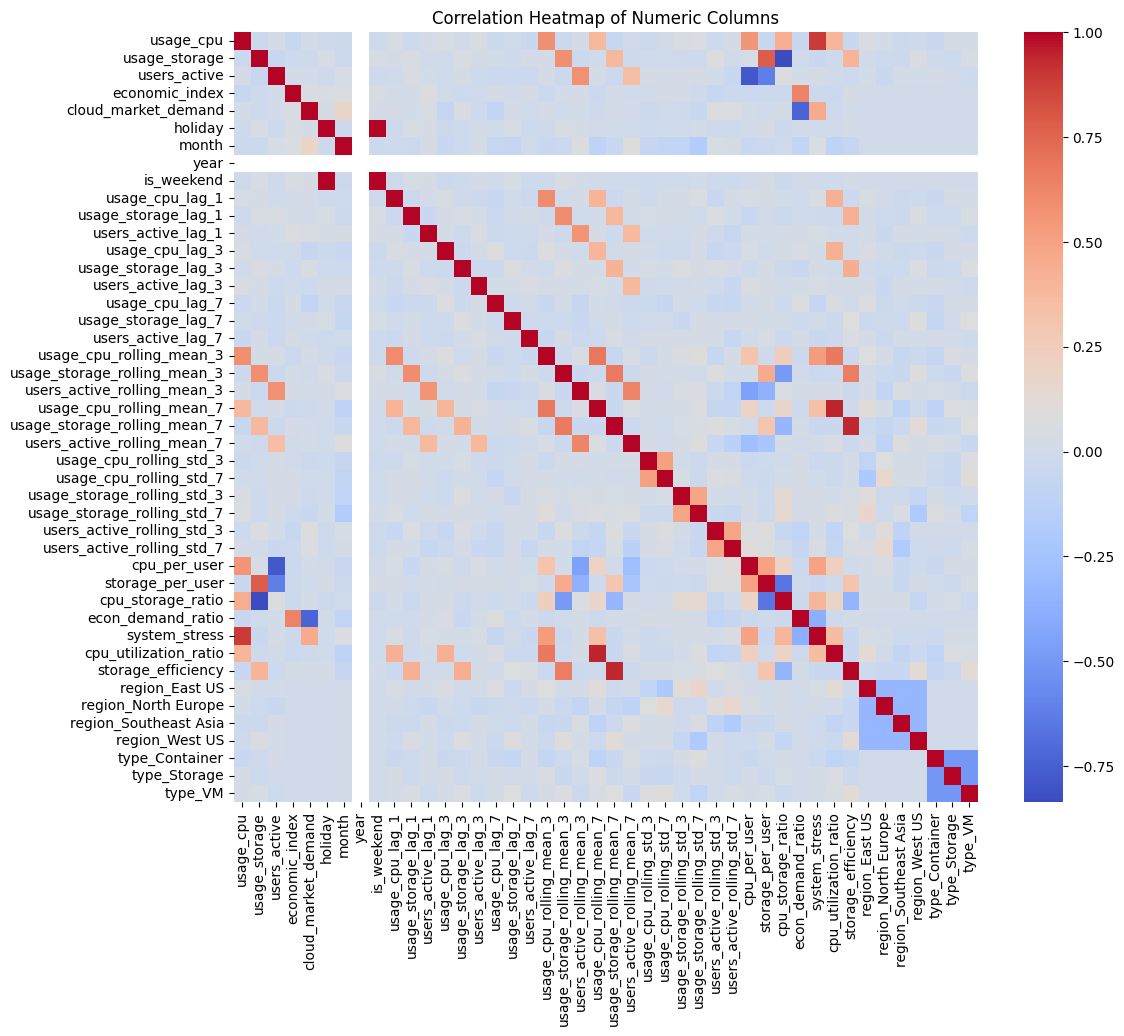

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

In [ ]:
df_encoded.to_csv('mlmodeltrainingdataset.csv', index=False)